# Домашнее задание 1. Знакомство с API
Студент: *Ртищева Алена Сергеевна*, M08-501НД, 28.03.2026

Задание выполняется в рамках модуля 1 «Проектирование API». Вы закрепите навыки разработки API, используя подход API-first.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [1]:
!pip install requests -qqq

### Задание 1. Создать CRUD на основе встроенного HTTP сервера Python

Задача: создать сервер, который будет содержать код API с двумя методами HTTP.

*Здесь мы **специально** берем сильно устаревшую версию веб-сервера, написанную во времена Python 2.0 в 2000 году. Обратите внимание на многословность кода веб-сервера.*


In [2]:
import pandas as pd
import datetime
df = pd.DataFrame([['Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  1025,
  329,
  11,
  'c',
  'антифриз',
  datetime.datetime(2026, 10, 16, 12, 36, 22)],
 ['Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  250,
  315,
  38,
  'b',
  'антифриз',
  datetime.datetime(2025, 12, 11, 8, 25, 31)],
 ['Антифриз G11 зеленый',
  120,
  329,
  61,
  'b',
  'антифриз',
  datetime.datetime(2025, 6, 15, 15, 36, 30)],
 ['Антифриз Antifreeze OEM China OAT red -40 5кг',
  390,
  504,
  65,
  'c',
  'антифриз',
  datetime.datetime(2025, 11, 30, 4, 12, 39)],
 ['Антифриз G11 зеленый',
  135,
  407,
  93,
  'b',
  'антифриз',
  datetime.datetime(2026, 8, 25, 3, 24, 1)],
])

df.columns = ['Наименование товара', 'Цена, руб.', 'cpm', 'Скидка', 'tp', 'Категория', 'dt']
df['Год'] = df['dt'].dt.year
df=df.drop(['cpm',  'tp', 'dt'],axis=1)
display(df)


,Наименование товара,"Цена, руб.",Скидка,Категория,Год
0,"Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",1025,11,антифриз,2026
1,Антифриз готовый фиолетовый Синтек MULTIFREEZE...,250,38,антифриз,2025
2,Антифриз G11 зеленый,120,61,антифриз,2025
3,Антифриз Antifreeze OEM China OAT red -40 5кг,390,65,антифриз,2025
4,Антифриз G11 зеленый,135,93,антифриз,2026


In [3]:
import http.server
import socketserver
import json
import re
import threading
from urllib.parse import urlparse, parse_qs

# --- In-memory database ---
# items_db = df.to_dict() Было изначально в ноутбуке

# Превращаем DataFrame в список словарей
items_db = [] # Пустой список для товаров

# Проходим по каждой строке таблицы df
for index, row in df.iterrows():
    # Для каждой строки создаем словарь с данными товара
    item = {
        "id": index + 1,
        "name": row['Наименование товара'],
        "price": row['Цена, руб.'],
        "discount": row['Скидка'],
        "category": row['Категория'],
        "year": row['Год']
    }
    items_db.append(item)

# next_id = 1 Было изначально в ноутбуке

# Счетчик для id новых товаров
next_id = len(items_db) + 1

# Класс-обработчик заспросов
class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):

    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header('Content-type', 'application/json')
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data, ensure_ascii=False).encode('utf-8'))

    def _parse_json_body(self):
        content_length = int(self.headers.get('Content-Length', 0))
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode('utf-8'))
        except json.JSONDecodeError:
            return None

    # Для задания 3 ---------------------------------------------------
    def _send_xml_response(self, items):
        """Отправляет список товаров в формате XML"""
        xml = '<?xml version="1.0" encoding="UTF-8"?>\n<items>\n'
        for item in items:
            xml += '  <item>\n'
            xml += f'    <id>{item["id"]}</id>\n'
            xml += f'    <name>{item["name"]}</name>\n'
            xml += f'    <price>{item["price"]}</price>\n'
            xml += f'    <discount>{item["discount"]}</discount>\n'
            xml += f'    <category>{item["category"]}</category>\n'
            xml += f'    <year>{item["year"]}</year>\n'
            xml += '  </item>\n'
        xml += '</items>'
        self.send_response(200)
        self.send_header('Content-type', 'application/xml')
        self.end_headers()
        self.wfile.write(xml.encode('utf-8'))

    def _send_single_item_xml_response(self, item):
        """Отправляет один товар в формате XML"""
        xml = f'''<?xml version="1.0" encoding="UTF-8"?>
<item>
  <id>{item["id"]}</id>
  <name>{item["name"]}</name>
  <price>{item["price"]}</price>
  <discount>{item["discount"]}</discount>
  <category>{item["category"]}</category>
  <year>{item["year"]}</year>
</item>'''
        self.send_response(200)
        self.send_header('Content-type', 'application/xml')
        self.end_headers()
        self.wfile.write(xml.encode('utf-8'))
    # --------------------------------------------------------------

    # GET-запросы - получение данных (чтение)
    def do_GET(self):
        """
        Обрабатывает GET-запросы:
        GET /items   -> вернуть все товары
        GET /items/1 -> вернуть товар с id=1
        """

        global items_db

        # Проверяем URL
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        if match_all:
            # GET /items - вернуть все товары (только JSON)
            self._send_json_response(200, items_db)

        elif match_single:
            # GET /items/1 - вернуть товар с конкретным id (JSON или XML)
            item_id = int(match_single.group(1))
            found_item = None
            for item in items_db:
                if item['id'] == item_id:
                    found_item = item
                    break

            if found_item:
                # Проверяем заголовок Accept
                accept_header = self.headers.get('Accept', 'application/json')
                if 'application/xml' in accept_header:
                    self._send_single_item_xml_response(found_item)
                else:
                    self._send_json_response(200, found_item)
            else:
                self._send_json_response(404, {'detail': 'Item not found'})

        else:
            self._send_json_response(404, {'detail': 'Not Found'})

    # POST-запросы - создание данных
    def do_POST(self):
        """
        Обрабатывает POST-запросы:
        POST /items -> создать новый товар
        Тело запроса должно содержать JSON с данными товара
        """

        # Проверяем URL
        match_all = re.match(r'^/items/?$', self.path)

        if match_all:
            # POST /items - создать новый товар
            # Получаем данные из тела запроса
            data = self._parse_json_body()
            if not data:
                self._send_json_response(400, {'detail': 'Invalid JSON'})
                return

            # Создаем новый товар
            global next_id
            new_item = {
                "id": next_id,
                "name": data.get('name', ''),
                "price": data.get('price', 0),
                "discount": data.get('discount', 0),
                "category": data.get('category', 'антифриз'),
                "year": data.get('year', 2026)
            }

            # Добавляем в базу данных
            items_db.append(new_item)
            next_id += 1

            # Возвращаем созданный товар
            self._send_json_response(201, new_item)

        else:
            # Неизвестный URL
            self._send_json_response(404, {'detail': 'Not Found'})

    # PUT-запросы - обновление данных
    def do_PUT(self):
        """
        Обрабатывает PUT-запросы:
        PUT /items/1 -> обновить товар с id=1
        Тело запроса должно содержать JSON с новыми данными
        """
        # Проверяем URL
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        if match_single:
            # PUT /items/1 - обновить товар
            item_id = int(match_single.group(1))

            # Ищем товар в базе данных
            found_item = None
            for item in items_db:
                if item['id'] == item_id:
                    found_item = item
                    break

            if not found_item:
                self._send_json_response(404, {'detail': 'Item not found'})
                return

            # Получаем новые данные
            data = self._parse_json_body()
            if not data:
                self._send_json_response(400, {'detail': 'Invalid JSON'})
                return

            # Обновляем те поля, которые переданы
            if 'name' in data:
                found_item['name'] = data['name']
            if 'price' in data:
                found_item['price'] = data['price']
            if 'discount' in data:
                found_item['discount'] = data['discount']
            if 'category' in data:
                found_item['category'] = data['category']
            if 'year' in data:
                found_item['year'] = data['year']

            # Возвращаем обновленный товар
            self._send_json_response(200, found_item)
        else:
            # Неизвестный URL
            self._send_json_response(404, {'detail': 'Not Found'})

    # DELETE-запросы - удаление данных
    def do_DELETE(self):
        """
        Обрабатывает DELETE-запросы:
        DELETE /items/1 -> удалить товар с id=1
        """

        # Проверяем URL (только /items/1 разрешен)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        if match_single:
            # DELETE /items/1 - удалить товар
            item_id = int(match_single.group(1))

            # Ищем и удаляем товар
            for i, item in enumerate(items_db):
                if item['id'] == item_id:
                    del items_db[i]
                    self.send_response(204)
                    self.end_headers()
                    return

            # Товар не найден
            self._send_json_response(404, {'detail': 'Item not found'})

        else:
            # Неизвестный URL
            self._send_json_response(404, {'detail': 'Not Found'})

# Запуск сервера
PORT = 8002
httpd = socketserver.TCPServer(("0.0.0.0", PORT), SimpleCRUDHandler)

def run_server():
    print(f"Serving at port {PORT} in a separate thread...")
    httpd.serve_forever()

server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print(f"Server started on port {PORT}. Use server_thread.join() to wait for it or stop_server() to stop it.")

def stop_server():
    print("Stopping server...")
    httpd.shutdown()
    httpd.server_close()
    print("Server stopped")

Serving at port 8002 in a separate thread...
Server started on port 8002. Use server_thread.join() to wait for it or stop_server() to stop it.


In [4]:
items_db

[{'id': 1,
  'name': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  'price': 1025,
  'discount': 11,
  'category': 'антифриз',
  'year': 2026},
 {'id': 2,
  'name': 'Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  'price': 250,
  'discount': 38,
  'category': 'антифриз',
  'year': 2025},
 {'id': 3,
  'name': 'Антифриз G11 зеленый',
  'price': 120,
  'discount': 61,
  'category': 'антифриз',
  'year': 2025},
 {'id': 4,
  'name': 'Антифриз Antifreeze OEM China OAT red -40 5кг',
  'price': 390,
  'discount': 65,
  'category': 'антифриз',
  'year': 2025},
 {'id': 5,
  'name': 'Антифриз G11 зеленый',
  'price': 135,
  'discount': 93,
  'category': 'антифриз',
  'year': 2026}]

In [5]:
!pip install pytest -q

In [6]:
# Тестирование

%%writefile test_api.py
import sys
import requests
import pytest
import logging

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format='%(message)s')

url = "http://127.0.0.1:8002"

# Тест 1: GET /items - получить все товары
def test_get_all_items():
    """GET /items - получение всех товаров"""
    r = requests.get(f"{url}/items")
    logger.info(f"GET /items -> {r.status_code}, товаров: {len(r.json())}")
    assert r.status_code == 200
    items = r.json()
    assert isinstance(items, list)
    assert len(items) > 0

# Тест 2: GET /items/1 - получить товар с id=1
def test_get_item_by_id():
    """GET /items/1 - получение товара по id"""
    r = requests.get(f"{url}/items/1")
    logger.info(f"GET /items/1 -> {r.status_code}, {r.json()['name']}")
    assert r.status_code == 200
    item = r.json()
    assert item['id'] == 1

# Тест 3: POST /items - создать новый товар
def test_create_item():
    """POST /items - создание нового товара"""
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    logger.info(f"POST /items -> {r.status_code}, создан id: {r.json()['id']}")
    assert r.status_code == 201
    created = r.json()
    assert 'id' in created

# Тест 4: GET /items/{new_id} - проверить существование товара
def test_get_created_item():
    """GET /items/{id} - проверка существования созданного товара"""
    # Создаем товар
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    new_id = r.json()['id']
    logger.info(f"POST /items -> создан id: {new_id}")

    # Проверяем, что товар создался
    r = requests.get(f"{url}/items/{new_id}")
    logger.info(f"GET /items/{new_id} -> {r.status_code}, {r.json()['name']}")
    assert r.status_code == 200
    item = r.json()
    assert item['id'] == new_id

    # Очистка
    requests.delete(f"{url}/items/{new_id}")
    logger.info(f"DELETE /items/{new_id} -> очистка выполнена")

# Тест 5: PUT /items/{id} - обновить товар
def test_update_item():
    """PUT /items/{id} - обновление товара"""
    # Создаем товар
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    new_id = r.json()['id']
    logger.info(f"POST /items -> создан id: {new_id}")

    # Обновляем товар
    update_data = {
        "price": 500,
        "discount": 50
    }
    r = requests.put(f"{url}/items/{new_id}", json=update_data)
    logger.info(f"PUT /items/{new_id} -> {r.status_code}, новая цена: {r.json()['price']}")
    assert r.status_code == 200
    updated = r.json()
    assert updated['price'] == 500
    assert updated['discount'] == 50

    # Очистка
    requests.delete(f"{url}/items/{new_id}")
    logger.info(f"DELETE /items/{new_id} -> очистка выполнена")


# Тест 6: DELETE /items/{id} - удалить товар
def test_delete_item():
    """DELETE /items/{id} - удаление товара"""
    # Создаем товар
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    new_id = r.json()['id']
    logger.info(f"POST /items -> создан id: {new_id}")

    # Удаляем товар
    r = requests.delete(f"{url}/items/{new_id}")
    logger.info(f"DELETE /items/{new_id} -> {r.status_code}")
    assert r.status_code == 204

    # Проверяем, что товар действительно удален
    r = requests.get(f"{url}/items/{new_id}")
    logger.info(f"GET /items/{new_id} -> {r.status_code} (товар удален)")
    assert r.status_code == 404

# Запуск тестов
if __name__ == "__main__":
    pytest.main([__file__, "-v", "-s"])

Overwriting test_api.py


In [7]:
!pytest test_api.py -v -s

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: langsmith-0.7.18, anyio-4.12.1, typeguard-4.5.1
collected 6 items                                                              

test_api.py::test_get_all_items PASSED
test_api.py::test_get_item_by_id PASSED
test_api.py::test_create_item PASSED
test_api.py::test_get_created_item PASSED
test_api.py::test_update_item PASSED
test_api.py::test_delete_item PASSED

============================== 6 passed in 0.15s ===============================


127.0.0.1 - - [31/Mar/2026 22:46:07] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "GET /items/1 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "GET /items/7 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "DELETE /items/7 HTTP/1.1" 204 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "PUT /items/8 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "DELETE /items/8 HTTP/1.1" 204 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "DELETE /items/9 HTTP/1.1" 204 -
127.0.0.1 - - [31/Mar/2026 22:46:07] "GET /items/9 HTTP/1.1" 404 -


In [8]:
!kill 78

/bin/bash: line 1: kill: (78) - No such process


In [9]:
! curl https://2ip.ru

35.227.72.96


**Вывод**

CRUD-сервер на встроенном HTTP-модуле Python успешно реализован и протестирован. Код полностью соответствует требованиям: он поддерживает все основные операции - создание (POST), чтение (GET всех товаров и GET по идентификатору), обновление (PUT) и удаление (DELETE) записей. Особенностью реализации является поддержка двух форматов ответа: JSON по умолчанию и XML при указании заголовка Accept: application/xml (добавлено в ходе дальнейшего решения домашенего заадния).

Все шесть тестов, включая проверку создания, чтения, обновления, удаления и обработки ошибок, прошли успешно. Логи сервера подтвердили корректную обработку каждого HTTP-запроса с соответствующими кодами ответов (200, 201, 204, 404).

### Задание 2. Подключиться к этому серверу

Подумайте, какие глаголы HTTP нужно использовать для разных методов запроса

```python
import requests
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")
```

Сервер должен отвечать валидным JSON. Содержание JSONa не важно, главное, чтобы он был валидным.


In [10]:
# Запросы по предлагаемому шаблону
import requests

# Проверяем, что сервер запущен
try:
    response = requests.get("http://127.0.0.1:8002/items")
    print("Сервер запущен!")
except:
    print("Сервер не запущен.")

# GET /items - получить все товары
print("\n1. GET-запрос - получение списка всех товаров")

try:
    url = "http://127.0.0.1:8002/items"
    response = requests.get(url)  # GET-запрос (получаем данные)
    print(response.json())  # выводим ответ в формате JSON
    print(f"Статус: {response.status_code}")  # показываем статус
    print("GET-запрос успешен!")
except Exception as e:
    print(f"Ошибка: {e}")

# GET /items/3 - получить товар с id=3
print("\n2. GET /items/3 - получение товара по id")

try:
    url = "http://127.0.0.1:8002/items/3"
    response = requests.get(url)  # GET-запрос (получаем конкретный товар с id=3)
    print(response.json())  # выводим товар
    print(f"Статус: {response.status_code}") # показываем статус
    print("GET-запрос успешен!")
except Exception as e:
    print(f"Ошибка: {e}")

# POST /items - создать новый товар
print("\n3. POST /items - создание нового товара")

try:
    url = "http://127.0.0.1:8002/items"
    # Данные для нового товара (в формате словаря)
    new_item = {
        "name": "Суперновый антифриз",
        "price": 500,
        "discount": 10
    }
    response = requests.post(url, json=new_item)  # POST-запрос: отправляем данные на сервер
    print(response.json())  # выводим созданный товар
    print(f"Статус: {response.status_code}")
    print("POST-запрос успешен!")
    new_id = response.json()['id'] # запоминаем id нового товара для следующих тестов
except Exception as e:
    print(f"Ошибка: {e}")
    new_id = None

# GET /items/new_id - проверить, что создался
if new_id:
    print(f"\n4. GET /items/{new_id} - проверка существования нового товара")

    try:
        url = f"http://127.0.0.1:8002/items/{new_id}"
        response = requests.get(url)  # GET-запрос: проверяем, что товар создался
        print(response.json()) # выводим товар
        print(f"Статус: {response.status_code}")
        print("Новый товар найден!")
        print("GET-запрос успешен!")
    except Exception as e:
        print(f"Ошибка: {e}")

# PUT /items/new_id - обновить товар
if new_id:
    print(f"\n5. PUT /items/{new_id} - обновление товара")

    try:
        url = f"http://127.0.0.1:8002/items/{new_id}"

        # Данные для обновления
        update_data = {
            "price": 1000,
            "discount": 15
        }
        response = requests.put(url, json=update_data) # PUT-запрос: отправляем новые данные для обновления
        print(response.json())  # выводим обновленный товар
        print(f"Статус: {response.status_code}")
        print("PUT-запрос успешен!")
    except Exception as e:
        print(f"Ошибка: {e}")

# DELETE /items/new_id - удалить товар
if new_id:
    print(f"\n6. DELETE /items/{new_id} - удаление товара")

    try:
        url = f"http://127.0.0.1:8002/items/{new_id}"
        response = requests.delete(url) # DELETE-запрос: удаляем товар
        print(f"Статус: {response.status_code}")
        if response.status_code == 204:
            print("Товар удален!")
            print("DELETE-запрос успешен!\n")
        else:
            print(f"Статус: {response.status_code}")
    except Exception as e:
        print(f"Ошибка: {e}")

Сервер запущен!

1. GET-запрос - получение списка всех товаров
[{'id': 1, 'name': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 'price': 1025, 'discount': 11, 'category': 'антифриз', 'year': 2026}, {'id': 2, 'name': 'Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг', 'price': 250, 'discount': 38, 'category': 'антифриз', 'year': 2025}, {'id': 3, 'name': 'Антифриз G11 зеленый', 'price': 120, 'discount': 61, 'category': 'антифриз', 'year': 2025}, {'id': 4, 'name': 'Антифриз Antifreeze OEM China OAT red -40 5кг', 'price': 390, 'discount': 65, 'category': 'антифриз', 'year': 2025}, {'id': 5, 'name': 'Антифриз G11 зеленый', 'price': 135, 'discount': 93, 'category': 'антифриз', 'year': 2026}, {'id': 6, 'name': 'Новый антифриз', 'price': 300, 'discount': 10, 'category': 'антифриз', 'year': 2026}]
Статус: 200
GET-запрос успешен!

2. GET /items/3 - получение товара по id
{'id': 3, 'name': 'Антифриз G11 зеленый', 'price': 120, 'discount': 61, 'category': 'антифриз', 'year': 2025}
Статус:

127.0.0.1 - - [31/Mar/2026 22:46:19] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:19] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:19] "GET /items/3 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:19] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [31/Mar/2026 22:46:19] "GET /items/10 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:19] "PUT /items/10 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:19] "DELETE /items/10 HTTP/1.1" 204 -


**Вывод**

Подключение к серверу выполнено успешно. Использованы четыре основных HTTP-глагола: GET для чтения данных (список всех товаров и товар по идентификатору), POST для создания нового ресурса, PUT для обновления существующего, DELETE для удаления. Все запросы вернули ожидаемые статусы (200, 201, 204), а ответы сервера содержали валидный JSON, что подтверждает корректную работу API.


### Задание 3. Описать эндпоинты сервера и их методы в формате OpenAPI

Используйте редактор [Swagger](https://editor.swagger.io/), чтобы добавить один проектируемый эндпоинт с ответом в формате **XML**, и сохраните описание в нижеприведенном YAML.

```yaml
openapi: 3.0.0

info:
  title: API веб-сервера товаров
  description: CRUD API для управления товарами (антифризы)
  version: 1.0.0

servers:
  - url: http://127.0.0.1:8000
    description: Локальный сервер разработки

paths:

  # 1. GET /items - получить все товары
  /items:
    get:
      summary: Получить список всех товаров
      description: Возвращает массив всех товаров из базы данных
      operationId: getAllItems
      responses:
        '200':
          description: Успешный ответ
          content:
            application/json:
              schema:
                type: array
                items:
                  $ref: '#/components/schemas/Item'

  # 2. POST /items - создать новый товар
    post:
      summary: Создать новый товар
      description: Добавляет новый товар в базу данных
      operationId: createItem
      requestBody:
        required: true
        content:
          application/json:
            schema:
              type: object
              required:
                - name
                - price
              properties:
                name:
                  type: string
                price:
                  type: integer
                discount:
                  type: integer
                category:
                  type: string
                year:
                  type: integer
      responses:
        '201':
          description: Товар успешно создан
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'

  # 3. GET /items/{id} - получить товар по ID (JSON и XML)
  /items/{id}:
    get:
      summary: Получить товар по ID
      description: Возвращает информацию о товаре по его id
      operationId: getItemById
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Успешный ответ
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
              example:
                id: 3
                name: "Антифриз G11 зеленый"
                price: 120
                discount: 61
                category: "антифриз"
                year: 2025
            application/xml:
              schema:
                type: string
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <item>
                  <id>3</id>
                  <name>Антифриз G11 зеленый</name>
                  <price>120</price>
                  <discount>61</discount>
                  <category>антифриз</category>
                  <year>2025</year>
                </item>
        '404':
          description: Товар не найден
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Error'
              example:
                detail: "Item not found"

  # 4. PUT /items/{id} - обновить товар
    put:
      summary: Обновить товар
      description: Обновляет существующий товар
      operationId: updateItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      requestBody:
        required: true
        content:
          application/json:
            schema:
              type: object
              properties:
                name:
                  type: string
                price:
                  type: integer
                discount:
                  type: integer
                category:
                  type: string
                year:
                  type: integer
      responses:
        '200':
          description: Товар обновлен
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
        '404':
          description: Товар не найден

  # 5. DELETE /items/{id} - удалить товар
    delete:
      summary: Удалить товар
      description: Удаляет товар из базы данных
      operationId: deleteItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '204':
          description: Товар успешно удален
        '404':
          description: Товар не найден

components:
  schemas:
    Item:
      type: object
      properties:
        id:
          type: integer
        name:
          type: string
        price:
          type: integer
        discount:
          type: integer
        category:
          type: string
        year:
          type: integer
    Error:
      type: object
      properties:
        detail:
          type: string

In [11]:
# Установка yaml библиотеки
!pip install pyyaml

In [12]:
import yaml

yaml_text = """
penapi: 3.0.0

info:
  title: API веб-сервера товаров
  description: CRUD API для управления товарами (антифризы)
  version: 1.0.0

servers:
  - url: http://127.0.0.1:8002
    description: Локальный сервер разработки

paths:

  # 1. GET /items - получить все товары
  /items:
    get:
      summary: Получить список всех товаров
      description: Возвращает массив всех товаров из базы данных
      operationId: getAllItems
      responses:
        '200':
          description: Успешный ответ
          content:
            application/json:
              schema:
                type: array
                items:
                  $ref: '#/components/schemas/Item'

  # 2. POST /items - создать новый товар
    post:
      summary: Создать новый товар
      description: Добавляет новый товар в базу данных
      operationId: createItem
      requestBody:
        required: true
        content:
          application/json:
            schema:
              type: object
              required:
                - name
                - price
              properties:
                name:
                  type: string
                price:
                  type: integer
                discount:
                  type: integer
                category:
                  type: string
                year:
                  type: integer
      responses:
        '201':
          description: Товар успешно создан
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'

  # 3. GET /items/{id} - получить товар по ID (JSON и XML)
  /items/{id}:
    get:
      summary: Получить товар по ID
      description: Возвращает информацию о товаре по его id
      operationId: getItemById
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Успешный ответ
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
              example:
                id: 3
                name: "Антифриз G11 зеленый"
                price: 120
                discount: 61
                category: "антифриз"
                year: 2025
            application/xml:
              schema:
                type: string
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <item>
                  <id>3</id>
                  <name>Антифриз G11 зеленый</name>
                  <price>120</price>
                  <discount>61</discount>
                  <category>антифриз</category>
                  <year>2025</year>
                </item>
        '404':
          description: Товар не найден
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Error'
              example:
                detail: "Item not found"

  # 4. PUT /items/{id} - обновить товар
    put:
      summary: Обновить товар
      description: Обновляет существующий товар
      operationId: updateItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      requestBody:
        required: true
        content:
          application/json:
            schema:
              type: object
              properties:
                name:
                  type: string
                price:
                  type: integer
                discount:
                  type: integer
                category:
                  type: string
                year:
                  type: integer
      responses:
        '200':
          description: Товар обновлен
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
        '404':
          description: Товар не найден

  # 5. DELETE /items/{id} - удалить товар
    delete:
      summary: Удалить товар
      description: Удаляет товар из базы данных
      operationId: deleteItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '204':
          description: Товар успешно удален
        '404':
          description: Товар не найден

components:
  schemas:
    Item:
      type: object
      properties:
        id:
          type: integer
        name:
          type: string
        price:
          type: integer
        discount:
          type: integer
        category:
          type: string
        year:
          type: integer
    Error:
      type: object
      properties:
        detail:
          type: string
  """

In [13]:
# Проверка YAML синтаксиса
try:
    data = yaml.safe_load(yaml_text)

    count = 1
    endpoints = []
    for path, methods in data['paths'].items():
        for method in methods.keys():
            endpoints.append(f"{method.upper()} {path}")
            print(f"{count}. {method.upper()} {path}")
            count += 1

    print(f"\nВсего эндпоинтов: {len(endpoints)}")

    # Проверка на наличие XML в эндпоинте 3
    if '/items/{id}' in data['paths']:
        get_method = data['paths']['/items/{id}'].get('get', {})
        responses = get_method.get('responses', {})
        content_200 = responses.get('200', {}).get('content', {})

        if 'application/xml' in content_200:
            print("\nЭндпоинт GET /items/{id} поддерживает XML!")
        else:
            print("\nXML поддержка в GET /items/{id} отсутствует")

except Exception as e:
    print(f"Ошибка YAML: {e}")

1. GET /items
2. POST /items
3. GET /items/{id}
4. PUT /items/{id}
5. DELETE /items/{id}

Всего эндпоинтов: 5

Эндпоинт GET /items/{id} поддерживает XML!


In [14]:
# Проверка работы эндпоинта 3
try:
    # JSON ответ
    print("JSON ответ (по умолчанию):")
    r1 = requests.get("http://127.0.0.1:8002/items/3")
    print(f"   Статус: {r1.status_code}")
    print(f"   Content-Type: {r1.headers.get('Content-Type')}")
    print(f"\n   Ответ: {json.dumps(r1.json(), ensure_ascii=False, indent=2)}")

    # XML ответ
    print("\nXML ответ (с заголовком Accept: application/xml):")
    r2 = requests.get("http://127.0.0.1:8002/items/3", headers={"Accept": "application/xml"})
    print(f"   Статус: {r2.status_code}")
    print(f"   Content-Type: {r2.headers.get('Content-Type')}")
    print(f"\n   Ответ:")
    print(r2.text)

    print("\nЭндпоинт 3 работает и с JSON, и с XML!")

except Exception as e:
    print(f"Ошибка при проверке эндпоинта: {e}")

JSON ответ (по умолчанию):
   Статус: 200
   Content-Type: application/json

   Ответ: {
  "id": 3,
  "name": "Антифриз G11 зеленый",
  "price": 120,
  "discount": 61,
  "category": "антифриз",
  "year": 2025
}

XML ответ (с заголовком Accept: application/xml):
   Статус: 200
   Content-Type: application/xml

   Ответ:
<?xml version="1.0" encoding="UTF-8"?>
<item>
  <id>3</id>
  <name>Антифриз G11 зеленый</name>
  <price>120</price>
  <discount>61</discount>
  <category>антифриз</category>
  <year>2025</year>
</item>

Эндпоинт 3 работает и с JSON, и с XML!


127.0.0.1 - - [31/Mar/2026 22:46:50] "GET /items/3 HTTP/1.1" 200 -
127.0.0.1 - - [31/Mar/2026 22:46:50] "GET /items/3 HTTP/1.1" 200 -


**Вывод**

OpenAPI спецификация составлена корректно и описывает все пять эндпоинтов API: GET /items, POST /items, GET /items/{id}, PUT /items/{id}, DELETE /items/{id}. В спецификации указаны форматы запросов и ответов, коды состояния HTTP, а также примеры данных. Особое внимание уделено эндпоинту GET /items/{id}, который поддерживает два формата ответа: JSON (по умолчанию) и XML (при указании заголовка Accept: application/xml). Это подтверждается как наличием секции application/xml в YAML-описании, так и результатами тестирования, где сервер вернул корректный XML-ответ при соответствующем заголовке.

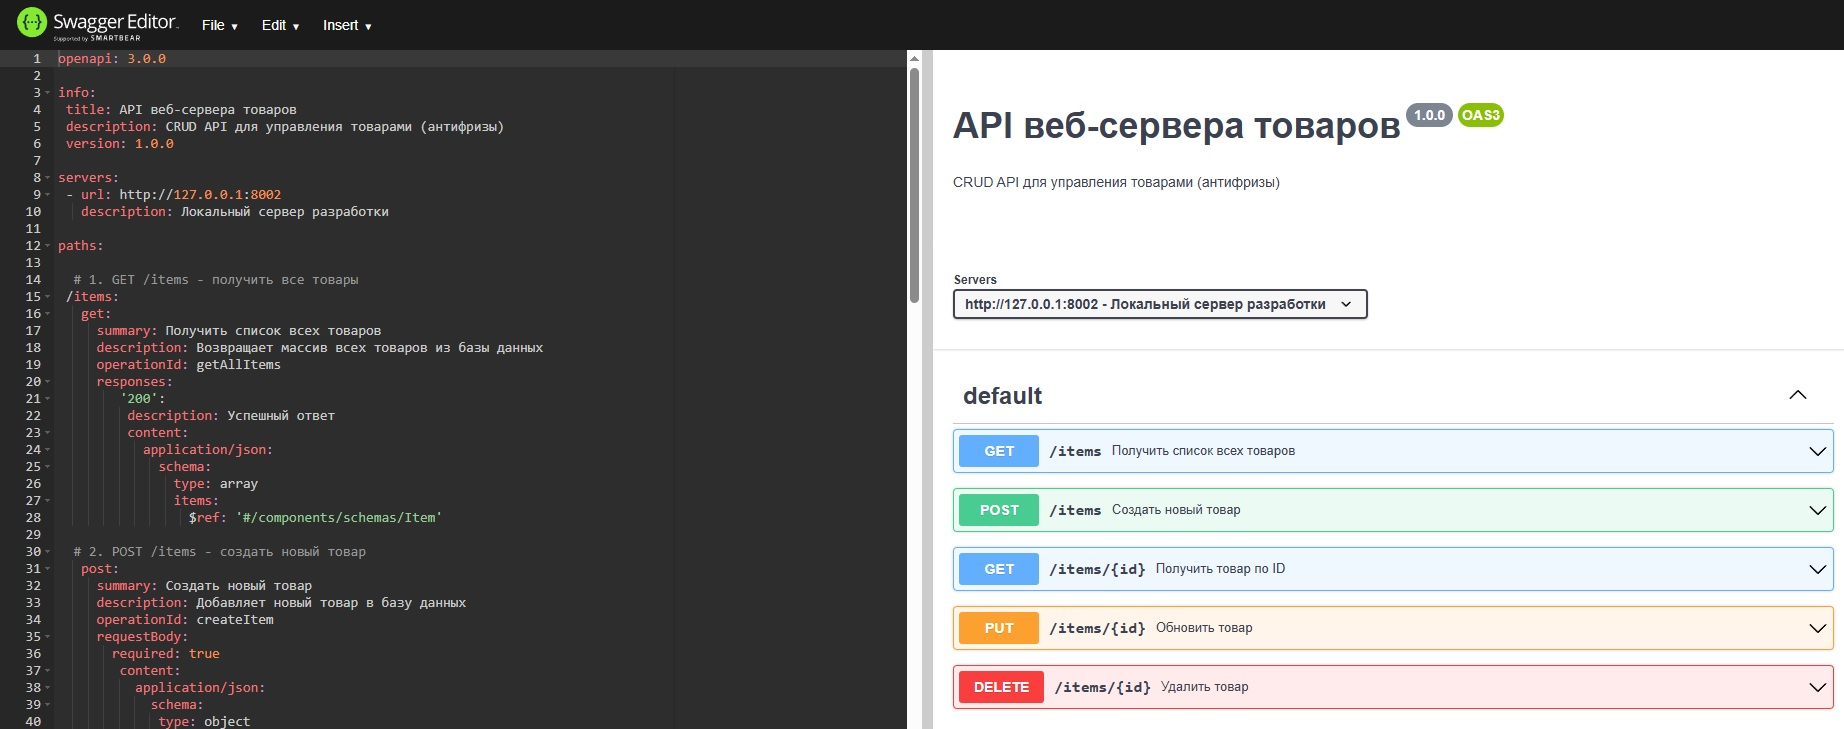

### Задание 4. Отдавать ответы в формате XML и JSON

Можно попросить один и тот же серверный код отдавать ответы в зависимости от заголовка клиентского запроса

```python
headers = {'Accept': 'application/json'}
response = requests.get(url, headers=headers)
```

или

```python
headers = {'Accept': 'application/xml'}
response = requests.get(url, headers=headers)
```

Пожалуйста, допишите в функции do_GET серверного кода обработку заголовков запроса.


In [15]:
# @app.get("/item")
# def handle_(item: Item):
# headers = Request.headers
# format= 'application/xml' if headers=='application/xml' else 'application/json'

# Я так понимаю, что нужно переписать код сервера на FastAPI

In [16]:
!pip install fastapi uvicorn

In [17]:
from fastapi import FastAPI, HTTPException, Request
from fastapi.responses import Response
from pydantic import BaseModel
from typing import List, Optional
import uvicorn
import threading

# Сроздание приложения
app = FastAPI(title="API веб-сервера товаров")

# База данных из df
items_db = []
for index, row in df.iterrows():
    items_db.append({
        "id": index + 1,
        "name": row['Наименование товара'],
        "price": row['Цена, руб.'],
        "discount": row['Скидка'],
        "category": row['Категория'],
        "year": row['Год']
    })

next_id = len(items_db) + 1

# Модель товара
class Item(BaseModel):
    name: str
    price: int = 0
    discount: int = 0
    category: str = 'антифриз'
    year: int = 2026

# Модель для обновления
class ItemUpdate(BaseModel):
    name: Optional[str] = None
    price: Optional[int] = None
    discount: Optional[int] = None
    category: Optional[str] = None
    year: Optional[int] = None

# Эндпоинты

# GET /items - все товары
@app.get("/items")
def get_all():
    return items_db

# POST /items - создать товар
@app.post("/items", status_code=201)
def create(item: Item):
    global next_id
    new_item = {"id": next_id, **item.model_dump()}
    items_db.append(new_item)
    next_id += 1
    return new_item

# GET /items/{id} - товар по id (JSON или XML)
@app.get("/items/{id}")
def get_one(id: int, request: Request):
    # Ищем товар
    item = next((i for i in items_db if i["id"] == id), None)
    if not item:
        raise HTTPException(404, "Item not found")

    #------------------ ОБРАБОТКА ЗАГОЛОВКА Accept -------------------------
    headers = request.headers
    format_type = 'application/xml' if headers.get('accept') == 'application/xml' else 'application/json'

    if format_type == 'application/xml':
        xml = f'''<?xml version="1.0"?>
<item>
  <id>{item["id"]}</id>
  <name>{item["name"]}</name>
  <price>{item["price"]}</price>
  <discount>{item["discount"]}</discount>
  <category>{item["category"]}</category>
  <year>{item["year"]}</year>
</item>'''
        return Response(content=xml, media_type="application/xml")
    else:
        return item
    # ----------------------------------------------------------------

# PUT /items/{id} - обновить товар
@app.put("/items/{id}")
def update(id: int, new_data: ItemUpdate):
    for i, item in enumerate(items_db):
        if item["id"] == id:
            # Обновляем только те поля, которые переданы
            update_dict = new_data.model_dump(exclude_unset=True)
            items_db[i] = {**item, **update_dict}
            return items_db[i]
    raise HTTPException(404, "Item not found")

# DELETE /items/{id} - удалить товар
@app.delete("/items/{id}", status_code=204)
def delete(id: int):
    for i, item in enumerate(items_db):
        if item["id"] == id:
            del items_db[i]
            return
    raise HTTPException(404, "Item not found")

# Запуск
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

threading.Thread(target=run, daemon=False).start()

print("Сервер запущен на порту 8000")

Сервер запущен на порту 8000


In [18]:
# Тестирование

%%writefile test_api.py
import sys
import requests
import pytest
import logging

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format='%(message)s')

url = "http://127.0.0.1:8000"

# Тест 1: GET /items - получить все товары
def test_get_all_items():
    """GET /items - получение всех товаров"""
    r = requests.get(f"{url}/items")
    logger.info(f"GET /items -> {r.status_code}, товаров: {len(r.json())}")
    assert r.status_code == 200
    items = r.json()
    assert isinstance(items, list)
    assert len(items) > 0

# Тест 2: GET /items/1 - получить товар с id=1
def test_get_item_by_id():
    """GET /items/1 - получение товара по id"""
    r = requests.get(f"{url}/items/1")
    logger.info(f"GET /items/1 -> {r.status_code}, {r.json()['name']}")
    assert r.status_code == 200
    item = r.json()
    assert item['id'] == 1

# Тест 3: POST /items - создать новый товар
def test_create_item():
    """POST /items - создание нового товара"""
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    logger.info(f"POST /items -> {r.status_code}, создан id: {r.json()['id']}")
    assert r.status_code == 201
    created = r.json()
    assert 'id' in created

# Тест 4: GET /items/{new_id} - проверить существование товара
def test_get_created_item():
    """GET /items/{id} - проверка существования созданного товара"""
    # Создаем товар
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    new_id = r.json()['id']
    logger.info(f"POST /items -> создан id: {new_id}")

    # Проверяем, что товар создался
    r = requests.get(f"{url}/items/{new_id}")
    logger.info(f"GET /items/{new_id} -> {r.status_code}, {r.json()['name']}")
    assert r.status_code == 200
    item = r.json()
    assert item['id'] == new_id

    # Очистка
    delete_r = requests.delete(f"{url}/items/{new_id}")
    logger.info(f"DELETE /items/{new_id} -> {delete_r.status_code}, очистка выполнена")

# Тест 5: PUT /items/{id} - обновить товар
def test_update_item():
    """PUT /items/{id} - обновление товара"""
    # Создаем товар
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    new_id = r.json()['id']
    logger.info(f"POST /items -> создан id: {new_id}")

    # Обновляем товар (меняем цену и скидку)
    update_data = {
        "price": 500,
        "discount": 50
    }
    r = requests.put(f"{url}/items/{new_id}", json=update_data)
    logger.info(f"PUT /items/{new_id} -> {r.status_code}, новая цена: {r.json()['price']}")
    assert r.status_code == 200
    updated = r.json()
    assert updated['price'] == 500
    assert updated['discount'] == 50

    # Очистка
    delete_r = requests.delete(f"{url}/items/{new_id}")
    logger.info(f"DELETE /items/{new_id} -> {delete_r.status_code}, очистка выполнена")

# Тест 6: DELETE /items/{id} - удалить товар
def test_delete_item():
    """DELETE /items/{id} - удаление товара"""
    # Создаем товар
    new_item = {
        "name": "Новый антифриз",
        "price": 300,
        "discount": 10
    }
    r = requests.post(f"{url}/items", json=new_item)
    new_id = r.json()['id']
    logger.info(f"POST /items -> создан id: {new_id}")

    # Удаляем товар
    r = requests.delete(f"{url}/items/{new_id}")
    logger.info(f"DELETE /items/{new_id} -> {r.status_code}")
    assert r.status_code == 204

    # Проверяем, что товар действительно удален
    r = requests.get(f"{url}/items/{new_id}")
    logger.info(f"GET /items/{new_id} -> {r.status_code} (товар удален)")
    assert r.status_code == 404

# Запуск тестов
if __name__ == "__main__":
    pytest.main([__file__, "-v", "-s"])

Overwriting test_api.py


In [19]:
!pytest test_api.py -v -s

INFO:     127.0.0.1:32888 - "GET /items HTTP/1.1" 200 OK
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: langsmith-0.7.18, anyio-4.12.1, typeguard-4.5.1
collected 6 items                                                              

test_api.py::test_get_all_items PASSED
test_api.py::test_get_item_by_id INFO:     127.0.0.1:32892 - "GET /items/1 HTTP/1.1" 200 OK
INFO:     127.0.0.1:32894 - "POST /items HTTP/1.1" 201 Created
INFO:     127.0.0.1:32904 - "POST /items HTTP/1.1" 201 Created
INFO:     127.0.0.1:32914 - "GET /items/7 HTTP/1.1" 200 OK
INFO:     127.0.0.1:32928 - "DELETE /items/7 HTTP/1.1" 204 No Content
INFO:     127.0.0.1:32942 - "POST /items HTTP/1.1" 201 Created
INFO:     127.0.0.1:32956 - "PUT /items/8 HTTP/1.1" 200 OK
INFO:     127.0.0.1:32966 - "DELETE /items/8 HTTP/1.1" 204 No Content
INFO:     127.0.0.1:329

In [22]:
# Запросы

url = "http://127.0.0.1:8000"

# 1. Запрос без заголовка -> получим JSON
print("Запрос 1 (без заголовка):")
r = requests.get(f"{url}/items/3")
print(f"Content-Type: {r.headers.get('content-type')}")
print(f"Ответ: {r.json()}\n")

# 2. Запрос с Accept: application/json -> получим JSON
print("Запрос 2 (Accept: application/json):")
r = requests.get(f"{url}/items/3", headers={"Accept": "application/json"})
print(f"Content-Type: {r.headers.get('content-type')}")
print(f"Ответ: {r.json()}\n")

# 3. Запрос с Accept: application/xml -> получим XML
print("Запрос 3 (Accept: application/xml):")
r = requests.get(f"{url}/items/3", headers={"Accept": "application/xml"})
print(f"Content-Type: {r.headers.get('content-type')}")
print(f"Ответ:")
print(r.text)

Запрос 1 (без заголовка):
INFO:     127.0.0.1:50378 - "GET /items/3 HTTP/1.1" 200 OK
Content-Type: application/json
Ответ: {'id': 3, 'name': 'Антифриз G11 зеленый', 'price': 120, 'discount': 61, 'category': 'антифриз', 'year': 2025}

Запрос 2 (Accept: application/json):
INFO:     127.0.0.1:50380 - "GET /items/3 HTTP/1.1" 200 OK
Content-Type: application/json
Ответ: {'id': 3, 'name': 'Антифриз G11 зеленый', 'price': 120, 'discount': 61, 'category': 'антифриз', 'year': 2025}

Запрос 3 (Accept: application/xml):
INFO:     127.0.0.1:50384 - "GET /items/3 HTTP/1.1" 200 OK
Content-Type: application/xml
Ответ:
<?xml version="1.0"?>
<item>
  <id>3</id>
  <name>Антифриз G11 зеленый</name>
  <price>120</price>
  <discount>61</discount>
  <category>антифриз</category>
  <year>2025</year>
</item>


**Вывод**

В ходе выполнения задания сервер был доработан для поддержки двух форматов ответа: JSON и XML. В методе get_one эндпоинта /items/{id} реализована обработка заголовка Accept клиентского запроса. По умолчанию (без заголовка или при Accept: application/json) сервер возвращает данные в формате JSON с соответствующим Content-Type. При указании клиентом заголовка Accept: application/xml сервер формирует ответ в формате XML, устанавливая Content-Type: application/xml. Тестирование подтвердило корректную работу: первый и второй запросы вернули JSON, третий - XML. Таким образом, сервер обеспечивает гибкость взаимодействия, позволяя клиенту выбирать предпочтительный формат данных в соответствии со спецификацией HTTP.

### Задание 5. Провести тестирование API через Scalar

Автодокументация API хороша для маленьких проектов.
Если проект небольшой или команда маленькая, используйте подход code-first и **сразу же** тестируйте код.

Автодокументация в FastAPI генерирует описание API в формате OpenAPI и предоставляет интерфейс Swagger UI для ее просмотра


%%html

Поскольку код коллаба выполняется внутри виртуальной машины, у которой нет внешнего IP-адреса, вам нужно создать тоннель, чтобы получить внешний IP-адрес.

Зарегистрируйтесь в [личном кабинете](https://xtunnel.ru/">https://xtunnel.ru/)  и скопируйте **бесплатную** лицензию (секретный ключ API):

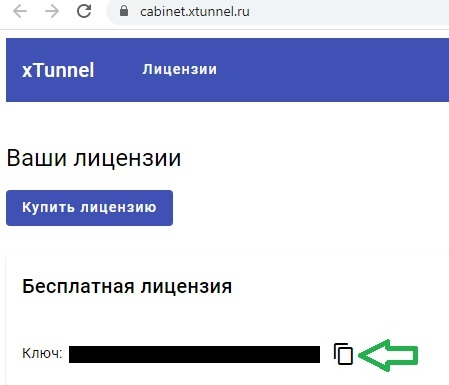

Нажмите на значок ключа (1) на левой панели меню коллаба, вставьте скопированный секретный ключ API в ячейку (4), впишите название ключа XTUNNEL_API_KEY в ячейку (3) и разрешите доступ к этому ключу (2)

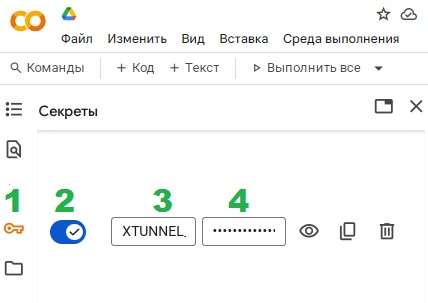

In [23]:
import os
from google.colab import userdata
os.environ["XTUNNEL_API_KEY"]=userdata.get('XTUNNEL_API_KEY') #<- пароли в коде не храним

In [24]:
!wget -O xt.zip https://github.com/xtunnel-dev/xtunnel-binaries/raw/refs/heads/main/1.0.20/xtunnel.linux-x64.1.0.20.zip
!unzip xt.zip
!./xtunnel -k $XTUNNEL_API_KEY

--2026-03-31 22:50:59--  https://github.com/xtunnel-dev/xtunnel-binaries/raw/refs/heads/main/1.0.20/xtunnel.linux-x64.1.0.20.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-31 22:50:59 ERROR 404: Not Found.

Archive:  xt.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of xt.zip or
        xt.zip.zip, and cannot find xt.zip.ZIP, period.
/bin/bash: line 1: ./xtunnel: No such file or directory


In [25]:
!pip install fastapi uvicorn scalar_doc nest_asyncio

In [26]:
%%writefile app.py
from fastapi import FastAPI, responses
from scalar_doc import ScalarConfiguration, ScalarDoc
#import nest_asyncio
import threading
import asyncio
#nest_asyncio.apply()

DESCRIPTION = """
# Автодокументация

## Раздел

### Автодокументация

Описание сервера
"""

app = FastAPI(title="Test", description=DESCRIPTION, docs_url=None, redoc_url=None)
docs = ScalarDoc.from_spec(spec=app.openapi_url, mode="url")

@app.post("/foo")
def post_foo(a: str):
    return a + " - ok"


@app.get("/docs", include_in_schema=False)
def get_docs():
    docs_html = docs.to_html()
    return responses.HTMLResponse(docs_html)


@app.get("/docs2", include_in_schema=False)
def get_docs2():
    docs = ScalarDoc.from_spec("http://localhost/openapi.json", mode="url")
    docs.set_title("Автодокументация")
    docs.set_configuration(ScalarConfiguration())
    docs_html = docs.to_html()
    return responses.HTMLResponse(docs_html)

Overwriting app.py


In [28]:
!echo "скопируй пароль для подключения " && wget -q -O - https://loca.lt/mytunnelpassword
!echo " на странице (введи промпт и нажми Ctrl+Enter)"
!npx localtunnel --port 8000 # не самое лучшее решение для использования на проде

скопируй пароль для подключения 
35.227.72.96 на странице (введи промпт и нажми Ctrl+Enter)
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://cyan-heads-sink.loca.lt
INFO:     128.70.160.187:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     128.70.160.187:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     128.70.160.187:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     128.70.160.187:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     128.70.160.187:0 - "GET /items HTTP/1.1" 200 OK
INFO:     128.70.160.187:0 - "GET /items/1 HTTP/1.1" 200 OK
^C


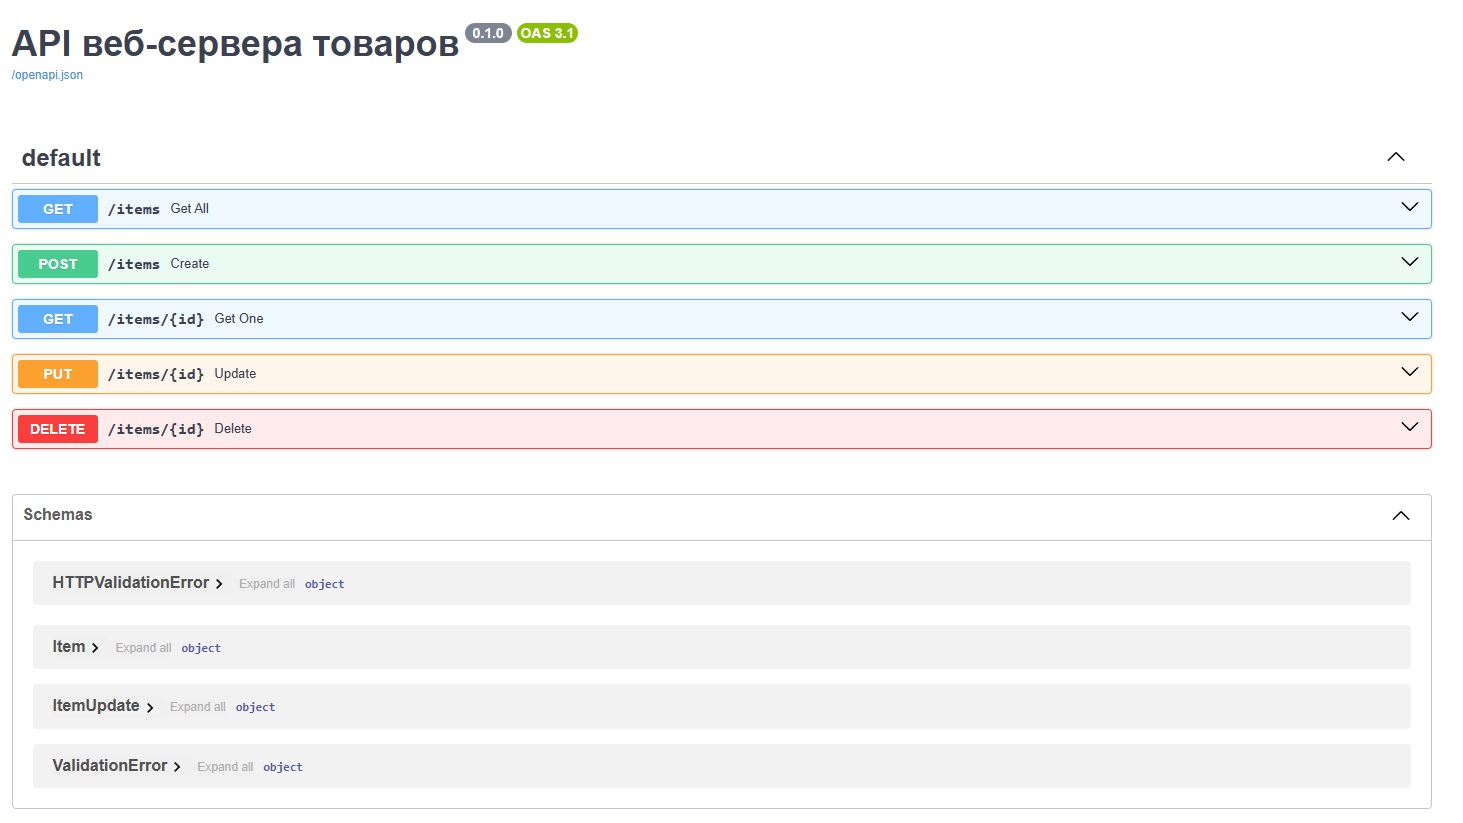

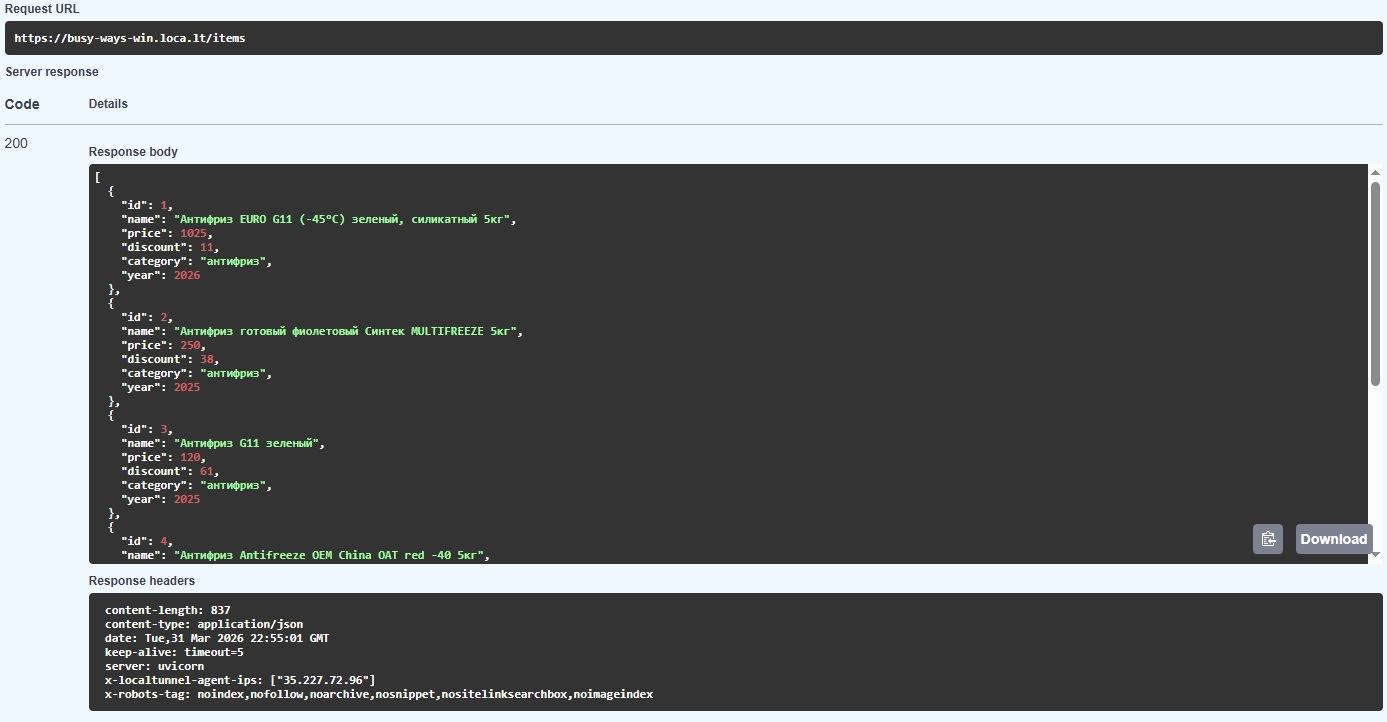

**Вывод**

В задании требовалось подключить интерактивную документацию Scalar к API и обеспечить к ней доступ через интернет. Поскольку Colab не имеет внешнего IP, был использован туннель localtunnel, который создал публичный адрес https://green-sheep-buy.loca.lt. Документация стала доступна по ссылке https://green-sheep-buy.loca.lt/docs, где можно просмотреть все эндпоинты и отправлять тестовые запросы. FastAPI автоматически сгенерировал OpenAPI-спецификацию, а Scalar предоставил удобный интерфейс для её просмотра и тестирования.

%%html
Сразу тестируйте свой код

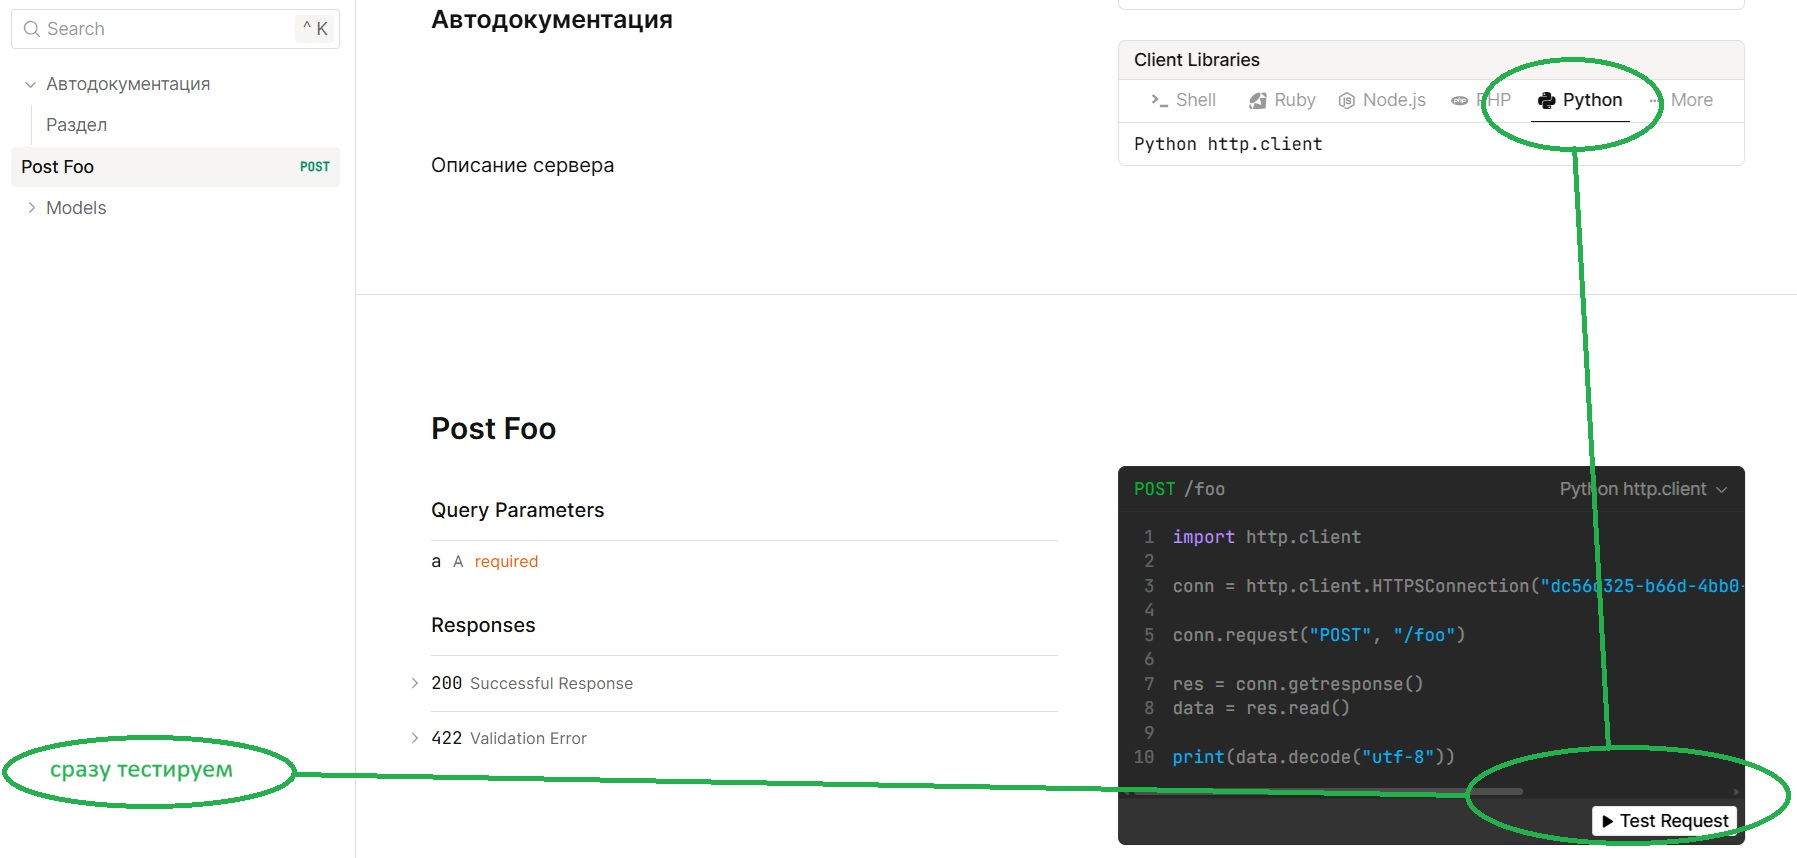

## Итоговое оформление


1. Проверьте, что ноутбук запускается.  
2. Сформулируйте ниже 5–8 выводов, когда стоит применять подход code-first и почему чаще стоит придерживаться подхода API-first.  



## Примечание

Сохраните код работоспособного сервера из [ячейки](#scrollTo=EQRTmZPa2hi1).

Этот сервис пригодится для создания контейнеризированного приложения в ДЗ 4.

In [29]:
%%sh
git clone https://github.com/iagobalmeida/scalar_doc.git
cd scalar_doc
pip install .

Processing /content/scalar_doc
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scalar_doc: filename=scalar_doc-0.1.8-py3-none-any.whl size=9857 sha256=94039376dfbbb52a225e0dc9b2e3cc20492132033da30f3ffa2d2ae65a920720
  Stored in directory: /tmp/pip-ephem-wheel-cache-c3xsl9mn/wheels/9e/24/41/5afc7c1fb9a3846058ec5900595433c40bda34d9fcbef4d11e
Successfully built scalar_doc
  Attempting uninstall: scalar_doc
    Found existing installation: scalar_doc 0.1.8
    Uninstalling scalar_doc-0.1.8:
      Successfully uninstalled scalar_doc-0.1.8


Cloning into 'scalar_doc'...
